<a href="https://colab.research.google.com/github/Waltermartinezc/customer-service-data-analysis/blob/main/MetricasAnalisisi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#1. Importar las herramientas de análisis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo visual de los gráficos
sns.set_theme(style="whitegrid")

# 2. Cargar nuestro dataset
df = pd.read_csv('customer_interactions.csv')

# 3. Mostrar las primeras 5 filas para verificar la carga
df.head()

,interaction_id,date,agent,channel,country,contact_reason,resolution,aht_seconds,csat,satisfaction,week,csat_positive,dsat
0,INT-0548,2026-07-01,Agent 010,Call,Spain,Refund Request,Resolved,877,4,Satisfied,27,1,0
1,INT-0915,2026-07-01,Agent 014,Chat,Portugal,Late Delivery,Resolved,535,5,Satisfied,27,1,0
2,INT-0064,2026-07-01,Agent 001,Email,Italy,Missing Items,Resolved,289,3,Neutral,27,0,0
3,INT-0060,2026-07-01,Agent 001,Chat,Spain,Late Delivery,Resolved,450,4,Satisfied,27,1,0
4,INT-0479,2026-07-01,Agent 004,Chat,Spain,Order Status,Resolved,409,5,Satisfied,27,1,0


In [2]:
# Ver un resumen técnico de nuestros datos (columnas, valores nulos y tipos de datos)
print("--- Información del Dataset ---")
df.info()

print("\n--- Estadísticas rápidas de CSAT y Tiempos (AHT) ---")
display(df[['csat', 'aht_seconds']].describe())

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   interaction_id  1000 non-null   object
 1   date            1000 non-null   object
 2   agent           1000 non-null   object
 3   channel         1000 non-null   object
 4   country         1000 non-null   object
 5   contact_reason  1000 non-null   object
 6   resolution      1000 non-null   object
 7   aht_seconds     1000 non-null   int64 
 8   csat            1000 non-null   int64 
 9   satisfaction    1000 non-null   object
 10  week            1000 non-null   int64 
 11  csat_positive   1000 non-null   int64 
 12  dsat            1000 non-null   int64 
dtypes: int64(5), object(8)
memory usage: 101.7+ KB

--- Estadísticas rápidas de CSAT y Tiempos (AHT) ---


,csat,aht_seconds
count,1000.000000,1000.00000
mean,3.653000,503.33800
std,1.046751,169.32923
min,1.000000,120.00000
25%,3.000000,385.00000
50%,4.000000,485.50000
75%,4.000000,606.25000
max,5.000000,1162.00000


/tmp/ipykernel_745/3014005384.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=motivos.values, y=motivos.index, palette='viridis')


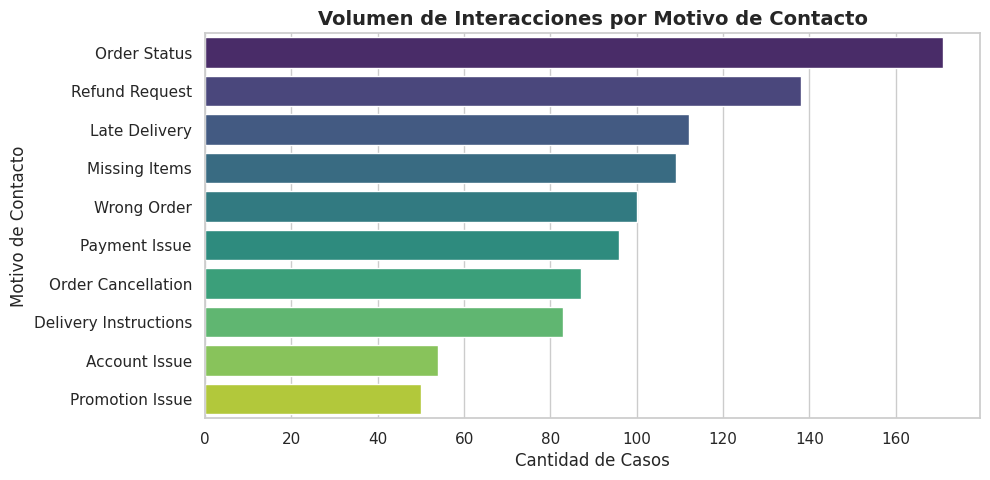

In [3]:
# 1. Contar cuántos casos tenemos por cada motivo de contacto
motivos = df['contact_reason'].value_counts()

# 2. Configurar el tamaño del gráfico
plt.figure(figsize=(10, 5))

# 3. Crear un gráfico de barras horizontales
sns.barplot(x=motivos.values, y=motivos.index, palette='viridis')

# 4. Agregar títulos y etiquetas para que se vea profesional
plt.title('Volumen de Interacciones por Motivo de Contacto', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Casos', fontsize=12)
plt.ylabel('Motivo de Contacto', fontsize=12)

# 5. Mostrar el gráfico
plt.show()

/tmp/ipykernel_745/2657702306.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=csat_por_canal.index, y=csat_por_canal.values, palette='coolwarm')


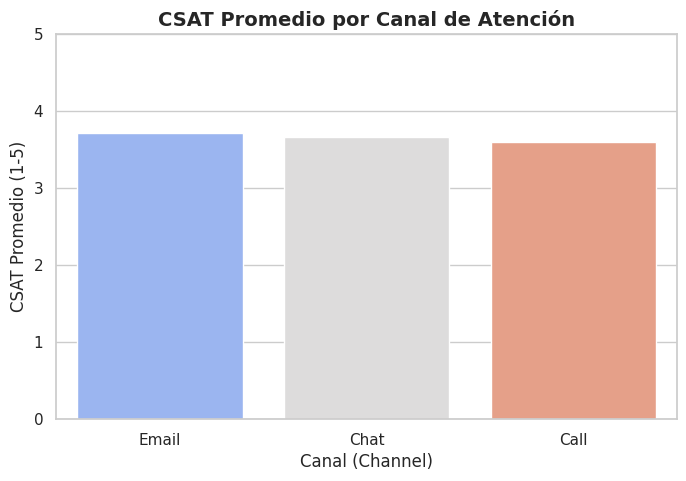

In [4]:
# 1. Calcular el CSAT promedio por canal de atención
csat_por_canal = df.groupby('channel')['csat'].mean().sort_values(ascending=False)

# 2. Configurar el tamaño del gráfico
plt.figure(figsize=(8, 5))

# 3. Crear el gráfico de barras
sns.barplot(x=csat_por_canal.index, y=csat_por_canal.values, palette='coolwarm')

# 4. Personalizar el gráfico
plt.title('CSAT Promedio por Canal de Atención', fontsize=14, fontweight='bold')
plt.xlabel('Canal (Channel)', fontsize=12)
plt.ylabel('CSAT Promedio (1-5)', fontsize=12)
plt.ylim(0, 5) # Para que la escala muestre del 0 al 5

# 5. Mostrar el resultado
plt.show()

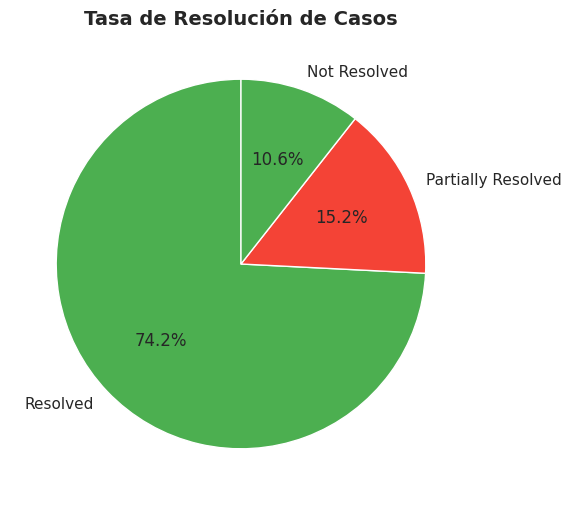

In [5]:
# 1. Calcular los porcentajes de resolución
resolucion = df['resolution'].value_counts(normalize=True) * 100

# 2. Crear un gráfico de pastel (pie chart)
plt.figure(figsize=(6, 6))
plt.pie(resolucion.values, labels=resolucion.index, autopct='%1.1f%%',
        colors=['#4CAF50', '#F44336'], startangle=90)

# 3. Título
plt.title('Tasa de Resolución de Casos', fontsize=14, fontweight='bold')

plt.show()